# Stage 11 — Mars inference

_Pipeline stage 11 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Applying the Earth-trained regime models to Mars

For each regime we recompute Mars embeddings with that regime's CNN, apply its combined
XGBoost, and threshold at the regime's operating point — yielding a touching
probability + decision per martian confluence pair. We report per-regime coupling
rates, the probability distributions, and **maps** of where coupling is predicted.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · Coupling rates per regime

In [2]:
rows = []
for r in REGIMES_:
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if not p.exists(): continue
    d = pd.read_parquet(p)
    rows.append({'regime': r, 'pairs': len(d), 'networks': d.network_id.nunique(),
                 'touching_%': round(100*d.pred_touching.mean(), 1),
                 'high_conf>=0.8_%': round(100*(d.prob_touching>=0.8).mean(), 1),
                 'mean_prob': round(d.prob_touching.mean(), 3)})
pd.DataFrame(rows)

,regime,pairs,networks,touching_%,high_conf>=0.8_%,mean_prob
0,regA,3682,391,53.0,45.7,0.668
1,regB,3682,391,64.1,61.7,0.739
2,regC,3682,391,38.6,34.3,0.595


### 2 · Probability distributions

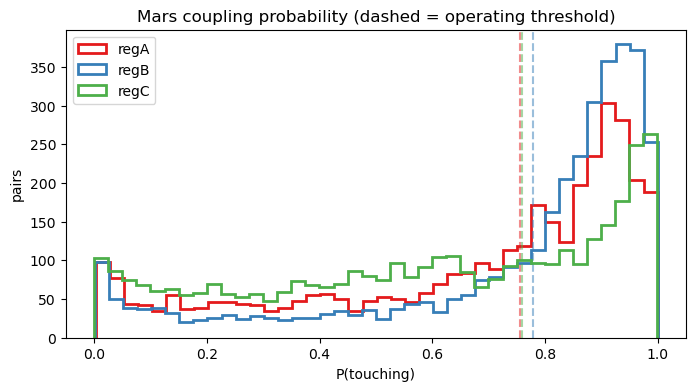

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for r in REGIMES_:
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if p.exists():
        d = pd.read_parquet(p)
        ax.hist(d.prob_touching, bins=40, histtype='step', lw=2, color=RC[r], label=r)
        ax.axvline(OP_THR[r], color=RC[r], ls='--', alpha=0.5)
ax.set_xlabel('P(touching)'); ax.set_ylabel('pairs')
ax.set_title('Mars coupling probability (dashed = operating threshold)'); ax.legend(); plt.show()

### 3 · Maps — predicted coupling across the valley networks (all three regimes)

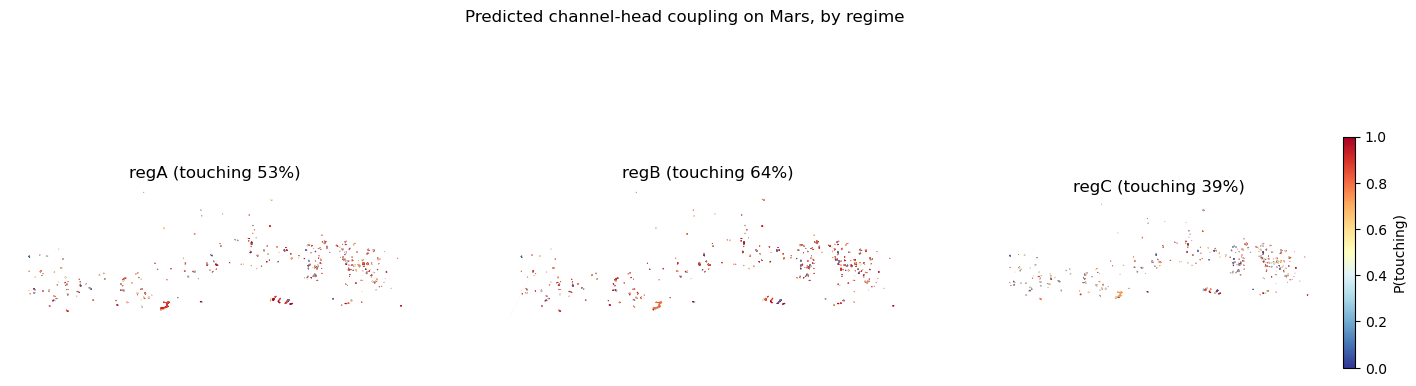

In [4]:
import geopandas as gpd
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, REGIMES_):
    g = MARS_OUT / f'mars_combined_{r}_predictions.gpkg'
    if g.exists():
        gdf = gpd.read_file(g, layer='pairs')
        gdf.plot(ax=ax, column='prob_touching', cmap='RdYlBu_r', linewidth=0.7,
                 vmin=0, vmax=1, legend=(r == REGIMES_[-1]),
                 legend_kwds={'label': 'P(touching)', 'shrink': 0.6})
        ax.set_title(f'{r} (touching {100*gdf.prob_touching.ge(OP_THR[r]).mean():.0f}%)')
    ax.set_aspect('equal'); ax.axis('off')
plt.suptitle('Predicted channel-head coupling on Mars, by regime'); plt.show()

**Takeaway.** Coupling is widespread across the martian valley networks in every
regime (regB highest, regC lowest — the dense/sparse ordering), with the high-confidence
fraction tracking the headline rate. The maps show coupling is not concentrated in a
few networks but distributed across the dissected highlands — consistent with mobile
divides having been a global feature of the valley-forming epoch.